# U.S. Flight Delay & Cancellation Hotspots

## 1. Overview / Introduction

Commercial air travel in the United States is frequently affected by delays and cancellations, which can disrupt passenger itineraries, increase operational costs for airlines, and create impacts across the national air transportation system. These disruptions are not uniformly distributed - some airports experience consistently worse performance than others, and delay patterns can shift across the year due to seasonal factors such as winter weather, peak summer demand, and holiday travel periods. Because airports are spatially fixed infrastructure nodes within a national network, geospatial analysis provides a  way to identify where disruption hotspots are present, and how these hotspots change over time.

This project uses geospatial data science methods on CyberGISX to analyze the spatial and seasonal patterns of U.S. flight delays and cancellations during 2024. This analysis focuses on three main goals:

1. **Seasonal hotspot shifts (airport-level):** Compute airport delay and cancellation metrics by season and map how hotspots change across the year.
2. **Worst-performing routes (route-level):** Compute delay metrics for origin-destination (OD) airport pairs and identify routes with the highest delay risk.
3. **Route contribution to worst airports:** Rank delay-prone routes that feed into the worst-performing airports to understand which connections most strongly contribute to delay burden.

### Research Questions
- **RQ1:** Which U.S. origin airports experience the highest average arrival delays and cancellation rates in 2024?
- **RQ2:** How do airport-level delay and cancellation hotspots shift across seasons (winter, spring, summer, fall)?
- **RQ3:** Which origin-destination routes are the worst-performing in terms of delays and cancellations?
- **RQ4:** Among the worst airports, which incoming routes contribute most to delay burden?

### Data Sources
This project combines flight performance records with airport location data:
- **Bureau of Transportation Statistics (BTS) TranStats (On-Time Performance):** Reporting Carrier On-Time Performance (1987–present), used here for 2024 flight records (ORIGIN, DEST, ARR_DELAY, DEP_DELAY, CANCELLED, YEAR, MONTH).
  - https://www.transtats.bts.gov/ontime/
  - https://transtats.bts.gov/DatabaseInfo.asp?QO_VQ=EFD
- **OurAirports (Airport Coordinates):** Open CSV dataset providing airport latitude/longitude and identifiers (e.g., iata_code) to map BTS airports to geographic locations.
  - https://ourairports.com/data/

### Planned Outputs
The final report and code will produce:
- Seasonal maps of airport delay severity and cancellation rates (hotspot comparison).
- Tables identifying the worst airports and worst routes.
- A ranked list of routes feeding into the worst airports (route contribution), with visualization between airport points.
- A concluding discussion summarizing spatial/seasonal patterns, key route findings, and limitations.

## 2. Data

This project uses two datasets:

### 2.1 BTS TranStats – Reporting Carrier On-Time Performance (2024)
The BTS on-time performance dataset provides flight-level records for U.S. commercial flights. In this project, the raw data contains the following columns:

`YEAR`, `MONTH`,  
`ORIGIN_AIRPORT_ID`, `ORIGIN_AIRPORT_SEQ_ID`, `ORIGIN_CITY_MARKET_ID`, `ORIGIN`, `ORIGIN_WAC`,  
`DEST_AIRPORT_ID`, `DEST_AIRPORT_SEQ_ID`, `DEST_CITY_MARKET_ID`, `DEST`, `DEST_WAC`,  
`DEP_DELAY`, `ARR_DELAY`, `CANCELLED`

For the analysis and visualizations in this report, the most relevant fields are:

- **Time:** `YEAR`, `MONTH` (used to define seasons and compare patterns across the year)
- **Airports (codes + IDs):**
  - `ORIGIN`, `DEST` (IATA airport codes used for joins to airport coordinates and for route analysis)
  - `ORIGIN_AIRPORT_ID`, `DEST_AIRPORT_ID` (BTS airport identifiers)
- **Region indicator:** `ORIGIN_WAC`, `DEST_WAC` (World Area Code)
- **Outcomes:**
  - `DEP_DELAY`, `ARR_DELAY` (delay minutes, used to compute average delay and delayed-flight rates)
  - `CANCELLED` (0/1, used to compute cancellation rates)

In the project directory, the 2024 BTS data is stored as 12 monthly ZIP files, one per month. Each ZIP contains a CSV named `T_ONTIME_REPORTING.csv`.

### 2.2 OurAirports – airports.csv (Airport Coordinates)
OurAirports provides airport identifiers and geographic coordinates used to map airports:
- `iata_code` (iata code for airport)
- `latitude_deg`, `longitude_deg`
- `name`, `iso_country` (country of airport)

Links:
- BTS TranStats On-Time: https://www.transtats.bts.gov/ontime/  
- BTS Database Info: https://transtats.bts.gov/DatabaseInfo.asp?QO_VQ=EFD  
- OurAirports downloads: https://ourairports.com/data/

### 2.3 Data Loading Plan

In this section, we will load the two datasets used in this project into the CyberGISX notebook:

1. **OurAirports (`airports.csv`)** to access airport coordinates (latitude/longitude) and identifiers (IATA codes).
2. **BTS TranStats On-Time Performance (2024)** stored as 12 monthly ZIP files (one per month), where each ZIP contains a CSV named `T_ONTIME_REPORTING.csv`.

After loading, we will inspect the dataset sizes and list the available columns to confirm that the fields needed for seasonal, airport-level, and route-level analysis are present.

In [6]:
# Import and locate BTS monthly ZIP files

import glob   
import zipfile
import pandas as pd

zip_files = sorted(glob.glob("Data/*.zip")) # Collect and sort all monthly BTS ZIP files in the Data folder  
print("Number of BTS ZIP files found:", len(zip_files)) # Confirm we have 12 monthly ZIP files for 2024
print("Example ZIP filenames:", zip_files[:3]) # Print a few ZIP filenames to verify the path pattern is correct 

Number of BTS ZIP files found: 12
Example ZIP filenames: ['Data/T_ONTIME_REPORTING_20260313_112310_JAN.zip', 'Data/T_ONTIME_REPORTING_20260313_112425_FEB.zip', 'Data/T_ONTIME_REPORTING_20260313_112542_APR.zip']


In [7]:
# Load OurAirports airport coordinates dataset

airports = pd.read_csv("airports.csv") # Read the OurAirports CSV into a DataFrame 

print("OurAirports shape (rows, cols):", airports.shape) # Report dataset dimensions to understand its size
print("OurAirports columns:", list(airports.columns)) # List columns so we can see which fields are available
airports.head() # Preview the first few rows to confirm the file loaded correctly

OurAirports shape (rows, cols): (84562, 19)
OurAirports columns: ['id', 'ident', 'type', 'name', 'latitude_deg', 'longitude_deg', 'elevation_ft', 'continent', 'iso_country', 'iso_region', 'municipality', 'scheduled_service', 'icao_code', 'iata_code', 'gps_code', 'local_code', 'home_link', 'wikipedia_link', 'keywords']


,id,ident,type,name,latitude_deg,longitude_deg,elevation_ft,continent,iso_country,iso_region,municipality,scheduled_service,icao_code,iata_code,gps_code,local_code,home_link,wikipedia_link,keywords
0,6523,00A,heliport,Total RF Heliport,40.070985,-74.933689,11.0,NaN,US,US-PA,Bensalem,no,NaN,NaN,K00A,00A,https://www.penndot.pa.gov/TravelInPA/airports...,NaN,NaN
1,323361,00AA,small_airport,Aero B Ranch Airport,38.704022,-101.473911,3435.0,NaN,US,US-KS,Leoti,no,NaN,NaN,00AA,00AA,NaN,NaN,NaN
2,6524,00AK,small_airport,Lowell Field,59.947733,-151.692524,450.0,NaN,US,US-AK,Anchor Point,no,NaN,NaN,00AK,00AK,NaN,NaN,NaN
3,6525,00AL,small_airport,Epps Airpark,34.864799,-86.770302,820.0,NaN,US,US-AL,Harvest,no,NaN,NaN,00AL,00AL,NaN,NaN,NaN
4,506791,00AN,small_airport,Katmai Lodge Airport,59.093287,-156.456699,80.0,NaN,US,US-AK,King Salmon,no,NaN,NaN,00AN,00AN,NaN,NaN,NaN


In [8]:
# Load and combine 2024 BTS on-time data from monthly ZIP files 

dfs = [] # Create an empty list to store each month’s DataFrame before concatenation 

for zpath in zip_files: # Loop over each monthly ZIP file path  
    with zipfile.ZipFile(zpath, "r") as z: # Open the ZIP file in read mode 
        with z.open("T_ONTIME_REPORTING.csv") as f: # Open the CSV inside the ZIP (same name for every month)  
            df = pd.read_csv(f, low_memory=False) # Read the CSV into a DataFrame (low_memory avoids dtype warnings) 
            dfs.append(df) # Append the month’s DataFrame to the list 

bts = pd.concat(dfs, ignore_index=True) # Combine all months into one DataFrame and reset the index 

print("Combined BTS shape (rows, cols):", bts.shape) # Report combined dataset dimensions 
print("Unique YEARS:", sorted(bts["YEAR"].unique())) # Confirm the combined dataset only contains year 2024 
print("Unique MONTHS:", sorted(bts["MONTH"].unique())) # Confirm the combined dataset includes months 1–12 
bts.head() # Preview the first few rows to confirm successful concatenation 

Combined BTS shape (rows, cols): (7079081, 15)
Unique YEARS: [2024]
Unique MONTHS: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


,YEAR,MONTH,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN_CITY_MARKET_ID,ORIGIN,ORIGIN_WAC,DEST_AIRPORT_ID,DEST_AIRPORT_SEQ_ID,DEST_CITY_MARKET_ID,DEST,DEST_WAC,DEP_DELAY,ARR_DELAY,CANCELLED
0,2024,1,10135,1013506,30135,ABE,23,10397,1039707,30397,ATL,34,-19.0,17.0,0.0
1,2024,1,10135,1013506,30135,ABE,23,10397,1039707,30397,ATL,34,-11.0,-28.0,0.0
2,2024,1,10135,1013506,30135,ABE,23,10397,1039707,30397,ATL,34,-11.0,-19.0,0.0
3,2024,1,10135,1013506,30135,ABE,23,10397,1039707,30397,ATL,34,-10.0,-34.0,0.0
4,2024,1,10135,1013506,30135,ABE,23,10397,1039707,30397,ATL,34,-10.0,14.0,0.0


In [11]:
# Inspect BTS columns and confirm required analysis fields are present

print("BTS columns:", list(bts.columns)) # Print all column names available in the BTS dataset

required_cols = ["YEAR","MONTH","ORIGIN_AIRPORT_ID","ORIGIN","ORIGIN_WAC","DEST_AIRPORT_ID","DEST","DEST_WAC","DEP_DELAY","ARR_DELAY","CANCELLED"] # Define the fields needed for this project’s analysis 
bts[required_cols].head() # Preview only the relevant columns to confirm they look correct

BTS columns: ['YEAR', 'MONTH', 'ORIGIN_AIRPORT_ID', 'ORIGIN_AIRPORT_SEQ_ID', 'ORIGIN_CITY_MARKET_ID', 'ORIGIN', 'ORIGIN_WAC', 'DEST_AIRPORT_ID', 'DEST_AIRPORT_SEQ_ID', 'DEST_CITY_MARKET_ID', 'DEST', 'DEST_WAC', 'DEP_DELAY', 'ARR_DELAY', 'CANCELLED']


,YEAR,MONTH,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_WAC,DEST_AIRPORT_ID,DEST,DEST_WAC,DEP_DELAY,ARR_DELAY,CANCELLED
0,2024,1,10135,ABE,23,10397,ATL,34,-19.0,17.0,0.0
1,2024,1,10135,ABE,23,10397,ATL,34,-11.0,-28.0,0.0
2,2024,1,10135,ABE,23,10397,ATL,34,-11.0,-19.0,0.0
3,2024,1,10135,ABE,23,10397,ATL,34,-10.0,-34.0,0.0
4,2024,1,10135,ABE,23,10397,ATL,34,-10.0,14.0,0.0


### What we observed after loading all the data

We successfully loaded and combined all 12 monthly BTS ZIP files into a single 2024 dataset. The combined BTS table contains 7,079,081 flight records and 15 columns, with `YEAR` confirming 2024 only and `MONTH` covering 1–12, which  means that the the full year is represented.

We also loaded the OurAirports dataset, which contains 84,562 airports and 19 columns, including the key fields needed for referencing airports (e.g., `iata_code`, `latitude_deg`, `longitude_deg`, `iso_country`).  

The BTS dataset includes the core variables needed for the rest of the project: time (`YEAR`, `MONTH`), airport identifiers (`ORIGIN`, `DEST`, and airport IDs/WAC codes), delay outcomes (`DEP_DELAY`, `ARR_DELAY`), and the cancellation indicator (`CANCELLED`). With these inputs confirmed, we can proceed to cleaning and feature engineering (defining seasons, separating canceled vs. non-canceled flights, and creating delay indicators) before computing seasonal airport metrics and route-level results.

## 3. Data Cleaning

In this section, we prepare the BTS flight records for seasonal, airport-level, and route-level analysis. We will:

- Create a `season` field from `MONTH` (Winter/Spring/Summer/Fall)
- Ensure `CANCELLED` is consistently treated as a numeric 0/1 indicator
- Create a non-cancelled subset for delay calculations (since delay minutes are not meaningful for canceled flights)
- Create delayed-flight indicators (arrival delay > 15 minutes) to support percentage-based metrics

These cleaned fields will be used in later sections to compute seasonal hotspot maps, identify the worst-performing routes, and rank routes contributing to the worst airports.

In [14]:
# Create season labels from MONTH

def month_to_season(m): # Convert numeric month to a season label
    if m in [12, 1, 2]: # Winter months
        return "Winter" # Assign Winter
    elif m in [3, 4, 5]: # Spring months
        return "Spring" # Assign Spring
    elif m in [6, 7, 8]: # Summer months
        return "Summer" # Assign Summer
    else: # Remaining months are Fall
        return "Fall" # Assign Fall

bts["season"] = bts["MONTH"].apply(month_to_season) # Create a season column for each flight record
bts[["YEAR", "MONTH", "season"]].drop_duplicates().sort_values(["MONTH"]).head(12) # Verify season mapping across months

,YEAR,MONTH,season
0,2024,1,Winter
547271,2024,2,Winter
1648697,2024,3,Spring
1066492,2024,4,Spring
2240464,2024,5,Spring
2850207,2024,6,Summer
3461339,2024,7,Summer
4095952,2024,8,Summer
4714977,2024,9,Fall
5297599,2024,10,Fall


In [16]:
# Ensure CANCELLED is numeric and create a non-canceled subset for delay metrics

bts["CANCELLED"] = pd.to_numeric(bts["CANCELLED"], errors="coerce") # Convert CANCELLED to numeric (0/1)
bts_nc = bts[bts["CANCELLED"] == 0].copy() # Create a dataset of non-canceled flights for delay calculations

print("Total flights:", len(bts)) # Count all flight records
print("Non-canceled flights:", len(bts_nc)) # Count non-canceled flight records
print("Canceled flights:", int((bts["CANCELLED"] == 1).sum())) # Count canceled flight records

Total flights: 7079081
Non-canceled flights: 6982766
Canceled flights: 96315


In [20]:
# Create delayed-flight indicators for arrival and departure delays

bts_nc["is_arr_delayed15"] = bts_nc["ARR_DELAY"] > 15 # Mark flights with arrival delay greater than 15 minutes
bts_nc["is_dep_delayed15"] = bts_nc["DEP_DELAY"] > 15 # Mark flights with departure delay greater than 15 minutes
print("Non-canceled flights with missing ARR_DELAY:", int(bts_nc["ARR_DELAY"].isna().sum())) # Check missing arrival delay values
print("Non-canceled flights with missing DEP_DELAY:", int(bts_nc["DEP_DELAY"].isna().sum())) # Check missing departure delay values
print("Percent arrival delayed > 15 (non-canceled):", bts_nc["is_arr_delayed15"].mean()) # Compute fraction of flights delayed on arrival
print("Percent departure delayed > 15 (non-canceled):", bts_nc["is_dep_delayed15"].mean()) # Compute fraction of flights delayed on departure

Non-canceled flights with missing ARR_DELAY: 17499
Non-canceled flights with missing DEP_DELAY: 0
Percent arrival delayed > 15 (non-canceled): 0.20097880982980096
Percent departure delayed > 15 (non-canceled): 0.19979303330514012


In [21]:
# Create a subset with non-missing ARR_DELAY for arrival-delay averages
bts_arr = bts_nc[bts_nc["ARR_DELAY"].notna()].copy() # Keep only non-canceled flights with ARR_DELAY present for average calculations
print("Non-canceled flights:", len(bts_nc)) # Total non-canceled flights used for percent-delayed metrics
print("Non-canceled flights with ARR_DELAY present:", len(bts_arr)) # Flights usable for average arrival delay

Non-canceled flights: 6982766
Non-canceled flights with ARR_DELAY present: 6965267


### What we observed after cleaning the data

We successfully created a `season` field from `MONTH`, confirming that all months in 2024 map correctly into Winter, Spring, Summer, and Fall. We also standardized `CANCELLED` as a numeric indicator and created a non-cancelled flight subset for delay analysis.

For delay metrics, we created indicators for whether a flight experienced an arrival or departure delay greater than 15 minutes. In the non-cancelled dataset, approximately 20% of flights were delayed by more than 15 minutes (both for arrival and departure). We also observed that `ARR_DELAY` contains a small number of missing values, so we created a separate subset (`bts_arr`) that excludes missing arrival delays for computing average arrival delay values.

With these cleaned fields and subsets in place, we can now compute airport-level performance metrics for 2024 overall and then do the same computations for seasonal comparisons.

## 4. Baseline Airport Metrics (2024 Overall)

In this section, we compute baseline airport-level performance metrics for the full year 2024. We aggregate flight records by origin airport to summarize:

- **Traffic volume:** total number of flights departing each airport
- **Cancellation rate:** percent of flights canceled at each origin
- **Average arrival delay:** mean `ARR_DELAY` for non-canceled flights with valid arrival delay values
- **Percent delayed (>15 min):** share of non-canceled flights with arrival delay greater than 15 minutes

These baseline metrics provide a year-wide reference before we compare how hotspots shift across seasons.

In [22]:
# Compute airport volume and cancellation rate by origin airport

airport_cancel = ( # Start an airport-level aggregation from the full BTS dataset
    bts.groupby("ORIGIN") # Group all flights by origin airport code
       .agg( # Compute summary statistics per origin airport
           total_flights=("ORIGIN", "size"), # Count total departing flights
           pct_cancelled=("CANCELLED", "mean") # Compute cancellation rate as the mean of 0/1 CANCELLED
       )
       .reset_index() # Convert the grouped index back into a regular column
) 

airport_cancel.sort_values("total_flights", ascending=False).head(10) # Preview busiest airports and their cancellation rates

,ORIGIN,total_flights,pct_cancelled
20,ATL,341910,0.009973
91,DFW,313582,0.018614
90,DEN,308645,0.011291
239,ORD,280052,0.013515
69,CLT,217574,0.013683
184,LAX,194053,0.008147
250,PHX,193551,0.006086
182,LAS,189252,0.008824
295,SEA,163725,0.011073
193,LGA,162432,0.023678


In [24]:
# Compute airport delay metrics by origin airport (non-canceled flights)

airport_delay = ( # Start an airport-level aggregation from the non-canceled dataset
    bts_nc.groupby("ORIGIN") # Group non-canceled flights by origin airport code
          .agg( # Compute delay-related statistics per origin airport
              pct_arr_delayed15=("is_arr_delayed15", "mean") # Percent of flights arriving > 15 minutes late
          )
          .reset_index() # Convert the grouped index back into a regular column
)
airport_avg_delay = ( # Start an airport-level aggregation for average arrival delay (requires non-missing ARR_DELAY)
    bts_arr.groupby("ORIGIN") # Group flights with valid ARR_DELAY by origin airport code
           .agg( # Compute average arrival delay per origin airport
               avg_arr_delay=("ARR_DELAY", "mean") # Mean arrival delay in minutes
           )
           .reset_index() # Convert the grouped index back into a regular column
)

airport_stats = airport_cancel.merge(airport_delay, on="ORIGIN", how="left") # Merge volume/cancel metrics with percent-delayed metrics
airport_stats = airport_stats.merge(airport_avg_delay, on="ORIGIN", how="left") # Merge in the average arrival delay metrics
airport_stats.sort_values("avg_arr_delay", ascending=False).head(10) # Preview the worst airports by average arrival delay

,ORIGIN,total_flights,pct_cancelled,pct_arr_delayed15,avg_arr_delay
213,MGW,37,0.000000,0.459459,69.054054
110,EWN,51,0.078431,0.361702,58.489362
155,HTS,426,0.032864,0.424757,41.864078
309,SMX,106,0.000000,0.320755,39.301887
66,CKB,207,0.024155,0.351485,35.425743
145,HGR,296,0.030405,0.348432,32.573427
156,HYA,269,0.033457,0.346154,32.220930
242,OTH,345,0.011594,0.304985,29.793510
319,STX,1196,0.011706,0.292724,25.457167
293,SCK,515,0.003883,0.356725,24.654971


### Ensuring “worst airports” results are meaningful

When we sort airports by average arrival delay using the full airport table, very small airports (with only a few dozen flights) can appear at the top of the list. These airports can have extreme averages due to small sample size, which makes them less useful for identifying major delay hotspots.

To make the worst airports analysis more representative, we will introduce a minimum flight-volume threshold and focus on airports with substantial traffic. This keeps the full dataset for mapping and computation, but uses a filtered subset for ranking and interpretation so results reflect consistently busy airports rather than small-sample outliers.

In [26]:
# Create a baseline subset with enough flights to make comparisons meaningful

airport_stats_sig = airport_stats[airport_stats["total_flights"] >= 2000].copy() # Keep airports with at least 2000 flights in 2024

print("Airports in full table:", len(airport_stats)) # Count all origin airports
print("Airports with >= 2000 flights:", len(airport_stats_sig)) # Count airports kept after thresholding
airport_stats_sig.sort_values("avg_arr_delay", ascending=False).head(10) # Preview worst major airports by average arrival delay

Airports in full table: 348
Airports with >= 2000 flights: 195


,ORIGIN,total_flights,pct_cancelled,pct_arr_delayed15,avg_arr_delay
19,ASE,7888,0.065416,0.297613,20.621048
112,EYW,7947,0.027180,0.252878,18.202637
103,EGE,3802,0.012362,0.238881,16.844260
170,JAC,5625,0.015111,0.219495,15.864545
318,STT,5538,0.010834,0.234392,14.868621
216,MIA,109944,0.017081,0.269641,14.296393
79,CRW,3433,0.011943,0.228479,14.088626
91,DFW,313582,0.018614,0.263049,13.908512
69,CLT,217574,0.013683,0.261844,13.904230
305,SJU,35431,0.012390,0.248457,13.828612


In [27]:
# Join airport-level metrics to OurAirports coordinates for mapping

airport_geo = airport_stats.merge(airports, left_on="ORIGIN", right_on="iata_code", how="left") # Attach airport coordinates and metadata using IATA code
missing_coords = airport_geo["latitude_deg"].isna().sum() # Count airports that did not find a coordinate match

print("Airport rows after join:", airport_geo.shape[0]) # Confirm number of airports after joining coordinates
print("Airports missing coordinates:", int(missing_coords)) # Report how many airports could not be georeferenced
airport_geo[["ORIGIN","name","iso_country","latitude_deg","longitude_deg","total_flights","pct_cancelled","pct_arr_delayed15","avg_arr_delay"]].head() # Preview joined fields

Airport rows after join: 348
Airports missing coordinates: 0


,ORIGIN,name,iso_country,latitude_deg,longitude_deg,total_flights,pct_cancelled,pct_arr_delayed15,avg_arr_delay
0,ABE,Lehigh Valley International Airport,US,40.651773,-75.442797,4337,0.016371,0.154008,3.202496
1,ABI,Abilene Regional Airport,US,32.411301,-99.681900,1757,0.008537,0.163031,4.409535
2,ABQ,Albuquerque International Sunport,US,35.039976,-106.608925,24092,0.008135,0.164002,4.291413
3,ABR,Aberdeen Regional Airport,US,45.449100,-98.421799,728,0.008242,0.175900,10.718837
4,ABY,Southwest Georgia Regional Airport,US,31.532946,-84.196215,765,0.009150,0.208443,15.914135


### What we observed from baseline airport metrics

We computed airport-level performance metrics for all 2024 flights aggregated by origin airport. The baseline table includes total departing flights, cancellation rate, average arrival delay (computed using non-canceled flights with valid `ARR_DELAY`), and the percent of flights arriving more than 15 minutes late.

When ranking airports by average arrival delay, we observed that very small airports can appear as extreme outliers due to low flight counts. To make the “worst airports” rankings more meaningful, we also created a high-volume subset (airports with at least 2,000 flights in 2024) and used that going forward. Finally, we joined the baseline airport metrics to OurAirports coordinates using IATA codes, successfully referencing all origin airports needed for mapping and seasonal comparisons.

## 5. Seasonal Hotspot Analysis

In this section, we will extend the baseline airport metrics by computing the same performance measures separately for each season in 2024. This allows us to compare how delay and cancellation hotspots shift across the year.

We will aggregate flights by (season, origin airport) and compute:
- total flights and cancellation rate (from all flights)
- average arrival delay (from non-canceled flights with valid `ARR_DELAY`)
- percent of flights delayed on arrival by more than 15 minutes (from non-canceled flights)

After computing these seasonal airport metrics, we will join airport coordinates and visualize seasonal hotspot patterns on maps.

In [31]:
# Compute seasonal flight volume and cancellation rate by origin airport

season_cancel = ( # Start seasonal airport-level aggregation from the full BTS dataset
    bts.groupby(["season", "ORIGIN"]) # Group flights by season and origin airport
       .agg( # Compute summary statistics for each (season, ORIGIN) pair
           total_flights=("ORIGIN", "size"), # Count total departing flights in that season
           pct_cancelled=("CANCELLED", "mean") # Compute cancellation rate for that season
       )
       .reset_index() # Convert grouped index back into regular columns
)
season_cancel.head() # Preview the seasonal cancellation table

,season,ORIGIN,total_flights,pct_cancelled
0,Fall,ABE,1001,0.014985
1,Fall,ABI,438,0.004566
2,Fall,ABQ,6428,0.003734
3,Fall,ABR,181,0.000000
4,Fall,ABY,199,0.005025


In [32]:
# Compute seasonal delay metrics by origin airport (non-canceled flights)

season_delay = ( # Start seasonal aggregation for percent delayed > 15 minutes
    bts_nc.groupby(["season", "ORIGIN"]) # Group non-canceled flights by season and origin airport
          .agg( # Compute percent delayed for each (season, ORIGIN) pair
              pct_arr_delayed15=("is_arr_delayed15", "mean") # Share of flights with ARR_DELAY > 15 minutes
          )
          .reset_index() # Convert grouped index back into regular columns
)

season_avg_delay = ( # Start seasonal aggregation for average arrival delay (requires non-missing ARR_DELAY)
    bts_arr.groupby(["season", "ORIGIN"]) # Group flights with valid ARR_DELAY by season and origin airport
           .agg( # Compute average arrival delay for each (season, ORIGIN) pair
               avg_arr_delay=("ARR_DELAY", "mean") # Mean arrival delay in minutes
           )
           .reset_index() # Convert grouped index back into regular columns
)

season_airport = season_cancel.merge(season_delay, on=["season", "ORIGIN"], how="left") # Merge seasonal volume/cancel with percent-delayed metrics
season_airport = season_airport.merge(season_avg_delay, on=["season", "ORIGIN"], how="left") # Merge in seasonal average arrival delay
season_airport.head() # Preview the combined seasonal airport metrics table

,season,ORIGIN,total_flights,pct_cancelled,pct_arr_delayed15,avg_arr_delay
0,Fall,ABE,1001,0.014985,0.106491,-3.182927
1,Fall,ABI,438,0.004566,0.096330,-3.100917
2,Fall,ABQ,6428,0.003734,0.120550,-0.682671
3,Fall,ABR,181,0.000000,0.132597,-1.784530
4,Fall,ABY,199,0.005025,0.151515,1.707071


In [33]:
# Join seasonal airport metrics to OurAirports coordinates for mapping

season_airport_geo = season_airport.merge(airports, left_on="ORIGIN", right_on="iata_code", how="left") # Attach coordinates and metadata for each origin airport

missing_coords = season_airport_geo["latitude_deg"].isna().sum() # Count seasonal airport rows missing coordinates

print("Season-airport rows after join:", season_airport_geo.shape[0]) # Confirm row count equals number of (season, ORIGIN) pairs
print("Season-airport rows missing coordinates:", int(missing_coords)) # Should be 0 or very small
season_airport_geo[["season","ORIGIN","name","latitude_deg","longitude_deg","total_flights","pct_cancelled","pct_arr_delayed15","avg_arr_delay"]].head() # Preview mapped fields

Season-airport rows after join: 1364
Season-airport rows missing coordinates: 0


,season,ORIGIN,name,latitude_deg,longitude_deg,total_flights,pct_cancelled,pct_arr_delayed15,avg_arr_delay
0,Fall,ABE,Lehigh Valley International Airport,40.651773,-75.442797,1001,0.014985,0.106491,-3.182927
1,Fall,ABI,Abilene Regional Airport,32.411301,-99.681900,438,0.004566,0.096330,-3.100917
2,Fall,ABQ,Albuquerque International Sunport,35.039976,-106.608925,6428,0.003734,0.120550,-0.682671
3,Fall,ABR,Aberdeen Regional Airport,45.449100,-98.421799,181,0.000000,0.132597,-1.784530
4,Fall,ABY,Southwest Georgia Regional Airport,31.532946,-84.196215,199,0.005025,0.151515,1.707071


In [38]:
# Create a seasonal subset with enough flights to make per season comparisons meaningful

season_airport_sig = season_airport_geo[season_airport_geo["total_flights"] >= 2000].copy() # Keep (season, airport) entries with at least 2000 flights in that season

print("Total (season, airport) rows:", len(season_airport_geo)) # Count all seasonal airport entries
print("(season, airport) rows with >= 2000 flights:", len(season_airport_sig)) # Count entries kept after thresholding

worst_by_season = ( # Build a table of worst airports per season by average arrival delay
    season_airport_sig.sort_values(["season", "avg_arr_delay"], ascending=[True, False]) # Sort within each season by avg delay descending
                     .groupby("season") # Group by season
                     .head(10) # Keep the top 10 worst airports per season
                     [["season","ORIGIN","name","total_flights","pct_cancelled","pct_arr_delayed15","avg_arr_delay"]] # Select key columns for display
)
worst_by_season # Display top 10 worst airports per season

Total (season, airport) rows: 1364
(season, airport) rows with >= 2000 flights: 438


,season,ORIGIN,name,total_flights,pct_cancelled,pct_arr_delayed15,avg_arr_delay
281,Fall,SAN,San Diego International Airport,24227,0.006728,0.224069,7.646407
23,Fall,AVL,Asheville Regional Airport,3096,0.072674,0.177290,5.299372
151,Fall,HSV,Huntsville International Airport,2254,0.002662,0.173043,4.891615
294,Fall,SGF,Springfield Branson National Airport,2583,0.003871,0.157792,4.847801
69,Fall,CLT,Charlotte Douglas International Airport,55925,0.009835,0.178510,3.983184
293,Fall,SFO,San Francisco International Airport,36506,0.006109,0.172643,3.608179
90,Fall,DFW,Dallas Fort Worth International Airport,79256,0.007608,0.178798,3.514110
54,Fall,BUR,Bobe Hope / Hollywood Burbank Airport,8368,0.008604,0.160680,2.960005
113,Fall,FAT,Fresno Yosemite International Airport,3158,0.005383,0.135944,2.180542
301,Fall,SJU,Luis Munoz Marin International Airport,7222,0.010800,0.155655,2.174273


### Seasonal hotspot maps

Now that we have seasonal airport metrics joined to coordinates, we will visualize delay hotspots by season using four maps (Winter, Spring, Summer, Fall).  
To keep the maps readable, we will plot only airports with a minimum number of flights within each season (so very small airports do not dominate the visualization).

In [43]:
# Choose a seasonal plotting subset for mapping

season_airport_map = season_airport_geo[season_airport_geo["total_flights"] >= 2000].copy() # Keep airports with at least 2000 flights in that season for clearer maps
seasons_order = ["Winter", "Spring", "Summer", "Fall"] # Define the season order for plotting

vmin = season_airport_map["avg_arr_delay"].min() # Set global minimum for the color scale across all seasons
vmax = season_airport_map["avg_arr_delay"].max() # Set global maximum for the color scale across all seasons
print("Rows to map:", len(season_airport_map)) # Confirm how many (season, airport) entries will be plotted
print("Color scale vmin:", vmin) # Print global min average delay for consistent color scaling
print("Color scale vmax:", vmax) # Print global max average delay for consistent color scaling

Rows to map: 438
Color scale vmin: -6.950129755667629
Color scale vmax: 29.516372795969772


/cvmfs/cybergis.illinois.edu/software/conda/cybergisx/python3-0.8.0/lib/python3.8/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naciscdn.org/naturalearth/50m/physical/ne_50m_land.zip
  warnings.warn('Downloading: {}'.format(url), DownloadWarning)
/cvmfs/cybergis.illinois.edu/software/conda/cybergisx/python3-0.8.0/lib/python3.8/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naciscdn.org/naturalearth/50m/physical/ne_50m_ocean.zip
  warnings.warn('Downloading: {}'.format(url), DownloadWarning)
/cvmfs/cybergis.illinois.edu/software/conda/cybergisx/python3-0.8.0/lib/python3.8/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naciscdn.org/naturalearth/50m/physical/ne_50m_coastline.zip
  warnings.warn('Downloading: {}'.format(url), DownloadWarning)
/cvmfs/cybergis.illinois.edu/software/conda/cybergisx/python3-0.8.0/lib/python3.8/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloadin

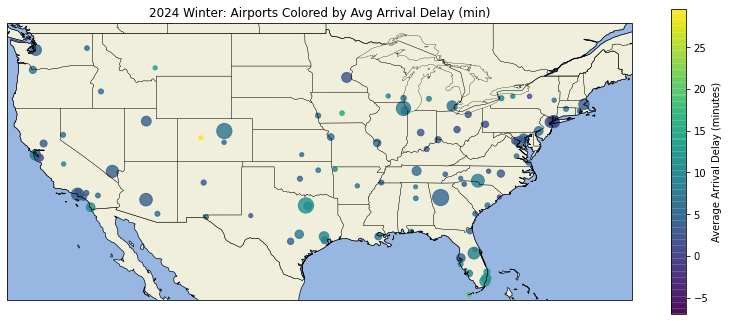

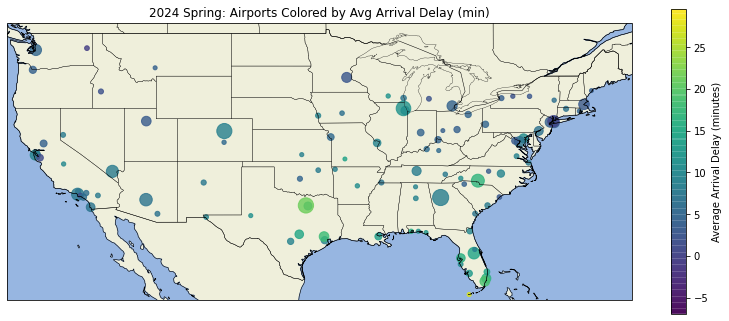

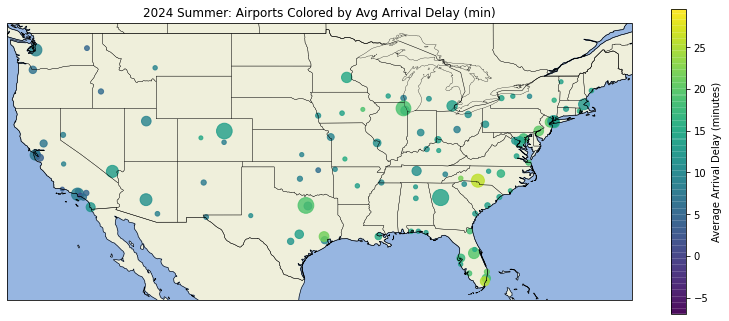

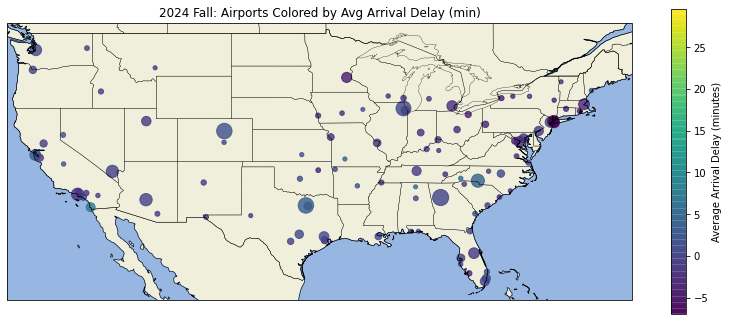

In [44]:
# Create 4 seasonal airport delay hotspot maps

import matplotlib.pyplot as plt # Plot figures and maps
import cartopy.crs as ccrs # Map projections for Cartopy
import cartopy.feature as cfeature # Basemap features (states, coastlines, etc.)

for s in seasons_order: # Loop through seasons in a consistent order
    df_s = season_airport_map[season_airport_map["season"] == s].copy() # Filter to one season of data
    
    fig = plt.figure(figsize=(14, 8)) # Create a figure for the season map
    ax = plt.axes(projection=ccrs.PlateCarree()) # Create a Cartopy axis in PlateCarree projection
    ax.set_title(f"2024 {s}: Airports Colored by Avg Arrival Delay (min)") # Set the season-specific map title
    
    ax.add_feature(cfeature.LAND) # Add land background
    ax.add_feature(cfeature.OCEAN) # Add ocean background
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6) # Add coastlines
    ax.add_feature(cfeature.BORDERS, linewidth=0.5) # Add country borders
    ax.add_feature(cfeature.STATES, linewidth=0.3) # Add U.S. state boundaries
    
    ax.set_extent([-125, -66.5, 24, 50], crs=ccrs.PlateCarree()) # Focus on the contiguous U.S.
    
    sizes = (df_s["total_flights"] / df_s["total_flights"].max()) * 250 + 10 # Scale point sizes by seasonal flight volume
    sc = ax.scatter( # Plot airports as points
        df_s["longitude_deg"], # X coordinate (longitude)
        df_s["latitude_deg"], # Y coordinate (latitude)
        c=df_s["avg_arr_delay"], # Color points by average arrival delay
        s=sizes, # Size points by flight volume
        alpha=0.8, # Set transparency
        vmin=vmin, # Use global min for consistent color scale
        vmax=vmax, # Use global max for consistent color scale
        transform=ccrs.PlateCarree() # Specify coordinate reference system
    ) 
    
    cbar = plt.colorbar(sc, ax=ax, shrink=0.7) # Add a colorbar
    cbar.set_label("Average Arrival Delay (minutes)") # Label the colorbar
    plt.show() # Display the map

### What we observed from the seasonal hotspot maps (2024)

Using a consistent color scale across seasons and focusing on airports with at least 2,000 flights per season, we can compare how average arrival delays shift over the year. Overall, the maps show that delay hotspots are not constant: some airports and regions appear more delay-prone in specific seasons, while others remain relatively stable.

Winter and summer show more prominent areas of higher average arrival delays at some major airports, which are consistent with seasonal disruption drivers (such as winter storms and de-icing impacts in winter, and high traffic volume and hot weather in summer). Fall appears visually lower on average across many airports, with fewer extreme hotspots. This seasonal variability leads into the next stage of the project: identifying whether particular origin–destination routes are responsible for sustained high delays and whether certain routes feed into the worst-performing airports.

## 6. Route-Level Analysis

In this section, we will compute delay and cancellation metrics for origin–destination (OD) airport pairs to identify the worst-performing routes in 2024. Route-level analysis helps move beyond airport-wide averages by showing which specific connections experience the most disruption.

We will aggregate flights by (ORIGIN, DEST) and compute:
- total flights on the route
- cancellation rate on the route
- average arrival delay for non-canceled flights with valid arrival delay values
- percent of non-canceled flights delayed on arrival by more than 15 minutes

To ensure route rankings are meaningful, we will apply a minimum flight-volume threshold so that routes with very few flights do not dominate the results.

In [46]:
# Compute route flight volume and cancellation rate by (ORIGIN, DEST)

route_cancel = ( # Start route-level aggregation from the full BTS dataset
    bts.groupby(["ORIGIN", "DEST"]) # Group flights by origin-destination pair
       .agg( # Compute route-level volume and cancellation rate
           route_flights=("ORIGIN", "size") # Count total flights on the route
           ,route_pct_cancelled=("CANCELLED", "mean") # Compute cancellation rate on the route
       )
       .reset_index() # Convert grouped index back into regular columns
)
route_cancel.sort_values("route_flights", ascending=False).head(10) # Preview the busiest routes

,ORIGIN,DEST,route_flights,route_pct_cancelled
4480,OGG,HNL,11642,0.010995
2667,HNL,OGG,11634,0.009541
3474,LAX,SFO,11526,0.009023
6031,SFO,LAX,11499,0.010088
3592,LGA,ORD,10971,0.022240
4675,ORD,LGA,10969,0.020604
3166,JFK,LAX,9915,0.003933
3425,LAX,JFK,9915,0.004438
1499,DCA,BOS,9658,0.016463
732,BOS,DCA,9657,0.015843


In [47]:
# Compute route delay metrics by (ORIGIN, DEST) using non-canceled flights

route_delay = ( # Start route-level aggregation for percent delayed > 15 minutes
    bts_nc.groupby(["ORIGIN", "DEST"]) # Group non-canceled flights by origin-destination pair
          .agg( # Compute percent delayed for each route
              route_pct_arr_delayed15=("is_arr_delayed15", "mean") # Share of flights with ARR_DELAY > 15 minutes
          )
          .reset_index() # Convert grouped index back into regular columns
)

route_avg_delay = ( # Start route-level aggregation for average arrival delay (requires non-missing ARR_DELAY)
    bts_arr.groupby(["ORIGIN", "DEST"]) # Group flights with valid ARR_DELAY by origin-destination pair
           .agg( # Compute average arrival delay for each route
               route_avg_arr_delay=("ARR_DELAY", "mean") # Mean arrival delay in minutes
           )
           .reset_index() # Convert grouped index back into regular columns
)
route_stats = route_cancel.merge(route_delay, on=["ORIGIN", "DEST"], how="left") # Merge route volume/cancel with percent-delayed metrics
route_stats = route_stats.merge(route_avg_delay, on=["ORIGIN", "DEST"], how="left") # Merge in route average arrival delay
print("Total routes:", len(route_stats)) # Count number of unique origin-destination routes in 2024
route_stats.head() # Preview the combined route metrics table

Total routes: 6805


,ORIGIN,DEST,route_flights,route_pct_cancelled,route_pct_arr_delayed15,route_avg_arr_delay
0,ABE,ATL,1017,0.013766,0.146560,0.669331
1,ABE,BNA,105,0.000000,0.133333,-10.000000
2,ABE,CLT,1166,0.012864,0.149435,4.445993
3,ABE,DEN,86,0.011628,0.188235,4.154762
4,ABE,FLL,81,0.000000,0.160494,-1.987654


### Ensuring “worst routes” results are meaningful

When ranking routes by average arrival delay, routes with very few flights can appear as extreme outliers due to small sample size. To make route comparisons more representative, we apply a minimum route threshold and focus on OD pairs with substantial traffic. This helps ensure the “worst routes” list reflects consistently busy routes rather than small anomalies.

In [49]:
# Filter to high-volume routes and identify worst-performing routes

route_stats_sig = route_stats[route_stats["route_flights"] >= 2000].copy() # Keep routes with at least 2000 flights in 2024

print("Total routes (all):", len(route_stats)) # Count all routes before thresholding
print("Routes with >= 2000 flights:", len(route_stats_sig)) # Count routes after thresholding

worst_routes = ( # Build a table of worst routes by average arrival delay
    route_stats_sig.sort_values("route_avg_arr_delay", ascending=False) # Sort routes by average arrival delay descending
                  [["ORIGIN","DEST","route_flights","route_pct_cancelled","route_pct_arr_delayed15","route_avg_arr_delay"]] # Select key columns
                  .head(20) # Keep the top 20 worst routes
)
worst_routes # Display the worst routes table

Total routes (all): 6805
Routes with >= 2000 flights: 1067


,ORIGIN,DEST,route_flights,route_pct_cancelled,route_pct_arr_delayed15,route_avg_arr_delay
349,AUS,DFW,4913,0.020354,0.237897,23.431156
4340,MSY,DFW,3027,0.020152,0.291976,23.267972
1222,CLT,PHL,3989,0.020055,0.317728,23.102715
1925,DFW,SAT,4548,0.023967,0.331156,22.329277
624,BNA,DFW,3587,0.030666,0.278113,22.294576
1918,DFW,RDU,2173,0.014726,0.314806,22.264513
1933,DFW,SFO,4061,0.015760,0.369527,21.371965
5663,SAN,SFO,6364,0.015399,0.382541,21.249359
4093,MIA,TPA,2602,0.028055,0.308027,20.534019
1170,CLT,EWR,3893,0.030054,0.307203,20.061653


### Route map: visualizing the worst-performing OD pairs

To complement the route-level tables, we will create a map that draws lines between origin and destination airports for the worst-performing high-volume routes. This uses vectors to represent OD connections and helps us visually identify where the most delay-prone routes are concentrated.

In [51]:
# Select top worst routes and attach origin/destination coordinates

N = 100
routes_to_map = route_stats_sig.sort_values("route_avg_arr_delay", ascending=False).head(N).copy() # Select the top N worst routes by average arrival delay

origin_coords = airports[["iata_code", "latitude_deg", "longitude_deg"]].copy() # Keep only the coordinate fields we need for origin airports
origin_coords = origin_coords.rename(columns={"iata_code": "ORIGIN", "latitude_deg": "orig_lat", "longitude_deg": "orig_lon"}) # Rename columns so we can merge on ORIGIN

dest_coords = airports[["iata_code", "latitude_deg", "longitude_deg"]].copy() # Keep only the coordinate fields we need for destination airports
dest_coords = dest_coords.rename(columns={"iata_code": "DEST", "latitude_deg": "dest_lat", "longitude_deg": "dest_lon"}) # Rename columns so we can merge on DEST

routes_to_map = routes_to_map.merge(origin_coords, on="ORIGIN", how="left") # Attach origin coordinates to each route
routes_to_map = routes_to_map.merge(dest_coords, on="DEST", how="left") # Attach destination coordinates to each route

print("Routes selected for mapping:", len(routes_to_map)) # Confirm how many routes we are mapping
print("Missing origin coords:", int(routes_to_map["orig_lat"].isna().sum())) # Check for missing origin coordinates after join
print("Missing destination coords:", int(routes_to_map["dest_lat"].isna().sum())) # Check for missing destination coordinates after join

routes_to_map[["ORIGIN","DEST","route_flights","route_avg_arr_delay","orig_lat","orig_lon","dest_lat","dest_lon"]].head() # Preview joined coordinate fields

Routes selected for mapping: 50
Missing origin coords: 0
Missing destination coords: 0


,ORIGIN,DEST,route_flights,route_avg_arr_delay,orig_lat,orig_lon,dest_lat,dest_lon
0,AUS,DFW,4913,23.431156,30.197535,-97.662015,32.896801,-97.038002
1,MSY,DFW,3027,23.267972,29.993401,-90.258003,32.896801,-97.038002
2,CLT,PHL,3989,23.102715,35.214001,-80.943100,39.871899,-75.241096
3,DFW,SAT,4548,22.329277,32.896801,-97.038002,29.533701,-98.469803
4,BNA,DFW,3587,22.294576,36.124500,-86.678200,32.896801,-97.038002


In [52]:
# Create LineString geometries for each route

from shapely.geometry import LineString

routes_to_map["geometry"] = routes_to_map.apply( # Create a geometry column using row-wise coordinate values
    lambda r: LineString([(r["orig_lon"], r["orig_lat"]), (r["dest_lon"], r["dest_lat"])]), axis=1 # Build a line from origin point to destination point
) # End geometry creation

routes_to_map[["ORIGIN","DEST","route_avg_arr_delay","geometry"]].head() # Preview route geometries

,ORIGIN,DEST,route_avg_arr_delay,geometry
0,AUS,DFW,23.431156,"LINESTRING (-97.662015 30.197535, -97.03800200..."
1,MSY,DFW,23.267972,"LINESTRING (-90.258003 29.993401, -97.03800200..."
2,CLT,PHL,23.102715,LINESTRING (-80.94309997558594 35.214000701904...
3,DFW,SAT,22.329277,"LINESTRING (-97.03800200000001 32.896801, -98...."
4,BNA,DFW,22.294576,"LINESTRING (-86.6782 36.1245, -97.038002000000..."


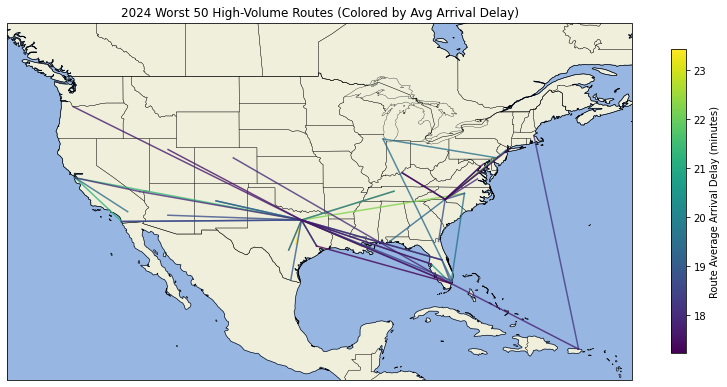

In [55]:
# Plot the worst routes as lines on a Cartopy map (colored by average arrival delay)

import matplotlib.pyplot as plt
import matplotlib as mpl 
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(14, 8)) # Create the figure for the route map
ax = plt.axes(projection=ccrs.PlateCarree()) # Create a Cartopy axis using PlateCarree projection

ax.set_title(f"2024 Worst {N} High-Volume Routes (Colored by Avg Arrival Delay)") # Add a title

ax.add_feature(cfeature.LAND) # Add land background
ax.add_feature(cfeature.OCEAN) # Add ocean background
ax.add_feature(cfeature.COASTLINE, linewidth=0.6) # Add coastlines
ax.add_feature(cfeature.BORDERS, linewidth=0.5) # Add country borders
ax.add_feature(cfeature.STATES, linewidth=0.3) # Add U.S. state boundaries
ax.set_extent([-130, -60, 15, 55], crs=ccrs.PlateCarree()) # Expand extent to include PR/VI

vmin = routes_to_map["route_avg_arr_delay"].min() # Set minimum value for line color scaling
vmax = routes_to_map["route_avg_arr_delay"].max() # Set maximum value for line color scaling
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax) # Normalize delay values into the [0,1] range for colormapping
cmap = plt.cm.viridis # Choose a colormap for delay severity

for _, r in routes_to_map.iterrows(): # Loop over each route row to plot its line geometry
    x, y = r["geometry"].xy # Extract x (lon) and y (lat) coordinates from the LineString
    ax.plot(x, y, linewidth=1.5, alpha=0.8, color=cmap(norm(r["route_avg_arr_delay"])), transform=ccrs.PlateCarree()) # Plot the route line colored by avg delay

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap) 
sm.set_array([]) 
cbar = plt.colorbar(sm, ax=ax, shrink=0.7) # Add a colorbar
cbar.set_label("Route Average Arrival Delay (minutes)") # Label the colorbar

plt.show() # Display the final route map

### Airport-level route risk map

In addition to mapping OD routes as lines, we can summarize route performance back to airports to create a choropleth-style airport map. Here, we compute an airport-level route risk metric by averaging the route delay values for each origin airport (using only high-volume routes). We then map airports as points colored by this route risk value to highlight which origin airports tend to be associated with more delay-prone routes overall.

In [56]:
# Compute an origin-airport route risk metric from high volume routes

route_stats_sig = route_stats[route_stats["route_flights"] >= 2000].copy() # Keep routes with at least 2000 flights in 2024

origin_route_risk = ( # Start aggregation to summarize route delay back to origin airports
    route_stats_sig.groupby("ORIGIN") # Group high-volume routes by origin airport
                  .agg( # Compute summary statistics for each origin airport
                      avg_route_delay=("route_avg_arr_delay", "mean") # Average of route average delays for that origin
                      ,total_route_flights=("route_flights", "sum") # Total flights across the kept high-volume routes
                      ,num_routes=("DEST", "nunique") # Number of unique destination airports among the kept routes
                  )
                  .reset_index() # Convert grouped index back into a regular column
)
origin_route_risk.sort_values("avg_route_delay", ascending=False).head(10) # Preview origins with highest route risk

,ORIGIN,avg_route_delay,total_route_flights,num_routes
88,PSP,19.410928,2294,1
115,XNA,17.004009,3290,1
68,MFE,15.864627,2673,1
69,MIA,14.887992,71835,19
30,DFW,14.463159,191534,53
4,ASE,14.201272,2852,1
22,CLT,13.949996,138024,44
47,ICT,13.754486,2678,1
20,CID,13.204253,2078,1
37,FLL,12.950311,52711,15


Origins mapped: 115


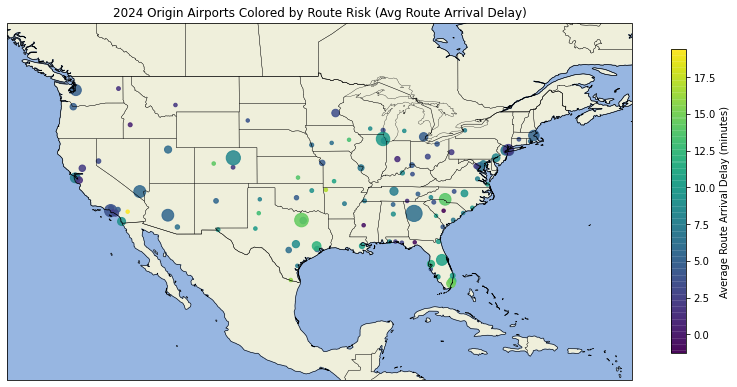

In [57]:
# Join origin route risk to coordinates and plot as a point-based choropleth-style map

origin_route_geo = origin_route_risk.merge(airports, left_on="ORIGIN", right_on="iata_code", how="left") # Attach airport coordinates using IATA code
origin_route_geo = origin_route_geo[(origin_route_geo["iso_country"] == "US") & (origin_route_geo["latitude_deg"].notna()) & (origin_route_geo["longitude_deg"].notna())].copy() # Keep airports with valid U.S. coordinates

print("Origins mapped:", len(origin_route_geo)) # Confirm number of origin airports included in the map



import cartopy.crs as ccrs 
import cartopy.feature as cfeature 

fig = plt.figure(figsize=(14, 8)) # Create the figure for the map
ax = plt.axes(projection=ccrs.PlateCarree()) # Create a Cartopy axis in PlateCarree projection

ax.set_title("2024 Origin Airports Colored by Route Risk (Avg Route Arrival Delay)") # Set title describing the metric

ax.add_feature(cfeature.LAND) # Add land background
ax.add_feature(cfeature.OCEAN) # Add ocean background
ax.add_feature(cfeature.COASTLINE, linewidth=0.6) # Add coastlines
ax.add_feature(cfeature.BORDERS, linewidth=0.5) # Add borders
ax.add_feature(cfeature.STATES, linewidth=0.3) # Add U.S. state lines
ax.set_extent([-130, -60, 15, 55], crs=ccrs.PlateCarree()) # Use the broader extent consistent with the route map

sizes = (origin_route_geo["total_route_flights"] / origin_route_geo["total_route_flights"].max()) * 250 + 10 # Scale point sizes by total route flights

sc = ax.scatter( # Plot origin airports as points
    origin_route_geo["longitude_deg"] # X coordinate (longitude)
    ,origin_route_geo["latitude_deg"] # Y coordinate (latitude)
    ,c=origin_route_geo["avg_route_delay"] # Color by route risk (average route delay)
    ,s=sizes # Size by total route flights
    ,alpha=0.85 # Set transparency
    ,transform=ccrs.PlateCarree() # Specify CRS for plotting
)

cbar = plt.colorbar(sc, ax=ax, shrink=0.7) # Add colorbar
cbar.set_label("Average Route Arrival Delay (minutes)") # Label the colorbar

plt.show() # Display map

### What we observed from route-level results (2024)

We computed route-level delay and cancellation metrics for high-volume origin–destination (OD) pairs and visualized the results in two ways.

First, the worst-routes line map plots the top 50 high-volume routes ranked by average arrival delay. Because all origin and destination coordinates were successfully matched (0 missing coordinates), each OD pair could be represented as a LineString. The map highlights that the most delay-prone routes are concentrated around a limited set of major hubs and corridors, with several of the worst routes involving large hub airports (multiple top-ranked routes connecting through DFW). The line visualization helps reveal how disruption can concentrate along specific connections rather than being uniformly distributed across the network.

Second, the airport-level route risk map summarizes route performance back to origin airports by computing an average route delay value across each origin’s high-volume routes. This provides a network-oriented view, where, rather than showing the average delay of flights departing an airport overall, it reflects how delay-prone that airport’s major OD connections tend to be. Airports with higher route-risk values indicate origins whose busiest routes are, on average, associated with larger arrival delays. Together, these maps and tables show that route structure matters: a relatively small number of high-volume OD pairs and hub-connected routes can account for a disproportionate share of delay-prone travel patterns.

From the maps, we observe that route-related delay risk is not spread evenly across the U.S. The worst-route line map shows many of the highest-delay, high-volume connections converging around a small set of hubs, most noticeably in the South/Central U.S. where multiple top routes connect through the Dallas–Fort Worth region. Several other high-delay links appear along major coastal and hub-to-hub corridors, indicating that the worst delays often occur on heavily traveled inter-airport connections rather than being isolated to a single region.

The route-risk airport map reinforces this pattern by showing that airports with larger route-risk values tend to align with major network nodes whose high-volume routes are consistently delay-prone. While many airports remain low-to-moderate risk, a smaller subset stands out with higher values, suggesting that these airports’ busiest connections are disproportionately associated with longer arrival delays. Overall these maps suggest that delay hotspots at the route level are strongly shaped by hub connectivity.

## 7. Routes Feeding Worst Airports

In this section, we identify which high-volume routes contribute most to delays at the worst-performing airports. We first define a set of worst airports using the airport-level metrics (restricted to airports with substantial traffic). Then, we subset the route table to routes whose destination is one of these worst airports (routes feeding into them). Finally, we rank these incoming routes using both average delay and a simple delay burden metric that combines delay severeness and and route volume.

In [59]:
# Select worst airports (high-volume) based on baseline 2024 airport metrics

K = 10 # Choose how many worst airports we will analyze
worst_airports = airport_stats_sig.sort_values("avg_arr_delay", ascending=False).head(K).copy() # Select top K worst airports by average arrival delay
worst_airport_codes = worst_airports["ORIGIN"].tolist() # Extract airport codes for filtering routes

worst_airports[["ORIGIN","total_flights","pct_cancelled","pct_arr_delayed15","avg_arr_delay"]] # Display the worst airports list

,ORIGIN,total_flights,pct_cancelled,pct_arr_delayed15,avg_arr_delay
19,ASE,7888,0.065416,0.297613,20.621048
112,EYW,7947,0.027180,0.252878,18.202637
103,EGE,3802,0.012362,0.238881,16.844260
170,JAC,5625,0.015111,0.219495,15.864545
318,STT,5538,0.010834,0.234392,14.868621
216,MIA,109944,0.017081,0.269641,14.296393
79,CRW,3433,0.011943,0.228479,14.088626
91,DFW,313582,0.018614,0.263049,13.908512
69,CLT,217574,0.013683,0.261844,13.904230
305,SJU,35431,0.012390,0.248457,13.828612


In [69]:
# Filter to routes feeding into the worst airports and rank by delay severity and burden

routes_into_worst = route_stats_sig[route_stats_sig["DEST"].isin(worst_airport_codes)].copy() # Keep high-volume routes whose destination is one of the worst airports
routes_into_worst["delay_burden"] = routes_into_worst["route_flights"] * routes_into_worst["route_avg_arr_delay"] # Compute a simple burden score combining volume and severity

print("High-volume routes feeding into worst airports:", len(routes_into_worst)) # Count how many routes remain after filtering

top_into_worst_by_delay = ( # Rank incoming routes by highest average arrival delay
    routes_into_worst.sort_values("route_avg_arr_delay", ascending=False) # Sort routes by average delay descending
                   [["ORIGIN","DEST","route_flights","route_pct_cancelled","route_pct_arr_delayed15","route_avg_arr_delay"]] # Select key columns
                   .head(200) # Keep top 200 routes
) 

top_into_worst_by_burden = ( # Rank incoming routes by highest delay burden (volume × delay)
    routes_into_worst.sort_values("delay_burden", ascending=False) # Sort routes by burden descending
                   [["ORIGIN","DEST","route_flights","route_avg_arr_delay","delay_burden","route_pct_cancelled","route_pct_arr_delayed15"]] # Select key columns
                   .head(200) # Keep top 200 routes
)
top_into_worst_by_delay # Display worst incoming routes by delay severity

High-volume routes feeding into worst airports: 123


,ORIGIN,DEST,route_flights,route_pct_cancelled,route_pct_arr_delayed15,route_avg_arr_delay
349,AUS,DFW,4913,0.020354,0.237897,23.431156
4340,MSY,DFW,3027,0.020152,0.291976,23.267972
624,BNA,DFW,3587,0.030666,0.278113,22.294576
2889,IAH,DFW,5264,0.028875,0.275430,19.789659
20,ABQ,DFW,2460,0.026829,0.224728,19.347589
...,...,...,...,...,...,...
2022,DTW,CLT,3890,0.008997,0.159533,3.533143
728,BOS,CLT,5214,0.015535,0.178258,2.638385
757,BOS,MIA,3788,0.015048,0.195926,2.534984
3396,LAX,CLT,2990,0.011037,0.149814,1.835202


In [70]:
# Display routes feeding into worst airports ranked by delay burden (volume × delay)
top_into_worst_by_burden 

,ORIGIN,DEST,route_flights,route_avg_arr_delay,delay_burden,route_pct_cancelled,route_pct_arr_delayed15
349,AUS,DFW,4913,23.431156,115117.271423,0.020354,0.237897
245,ATL,MIA,6699,16.974708,113713.572013,0.011345,0.266647
194,ATL,DFW,6523,16.579351,108147.109196,0.016557,0.268589
2889,IAH,DFW,5264,19.789659,104172.766157,0.028875,0.275430
3402,LAX,DFW,7018,13.953795,97927.732619,0.012539,0.231025
...,...,...,...,...,...,...,...
4230,MSP,CLT,2535,4.690771,11891.104674,0.009073,0.203822
2806,IAD,CLT,2126,4.816579,10240.047642,0.010818,0.166904
757,BOS,MIA,3788,2.534984,9602.518837,0.015048,0.195926
3396,LAX,CLT,2990,1.835202,5487.254502,0.011037,0.149814


### Map of routes feeding into the worst airports

To visualize which connections contribute most to delays at the worst-performing airports, we map the highest-impact incoming routes (filtered to high-volume routes whose destination is one of the worst airports). Each line represents an origin–destination pair, and line color reflects either average delay severity or overall delay burden.

In [75]:
# Select top incoming routes and attach origin/destination coordinates

N = 50 # Choose how many incoming routes we will map
routes_in_map = routes_into_worst.sort_values("delay_burden", ascending=False).head(N).copy() # Select top N incoming routes by delay burden

origin_coords = airports[["iata_code", "latitude_deg", "longitude_deg"]].copy() # Keep coordinate fields for origins
origin_coords = origin_coords.rename(columns={"iata_code": "ORIGIN", "latitude_deg": "orig_lat", "longitude_deg": "orig_lon"}) # Rename for ORIGIN join

dest_coords = airports[["iata_code", "latitude_deg", "longitude_deg"]].copy() # Keep coordinate fields for destinations
dest_coords = dest_coords.rename(columns={"iata_code": "DEST", "latitude_deg": "dest_lat", "longitude_deg": "dest_lon"}) # Rename for DEST join

routes_in_map = routes_in_map.merge(origin_coords, on="ORIGIN", how="left") # Attach origin coordinates
routes_in_map = routes_in_map.merge(dest_coords, on="DEST", how="left") # Attach destination coordinates

print("Incoming routes selected for mapping:", len(routes_in_map)) # Confirm selection size
print("Missing origin coords:", int(routes_in_map["orig_lat"].isna().sum())) # Check origin coordinate coverage
print("Missing destination coords:", int(routes_in_map["dest_lat"].isna().sum())) # Check destination coordinate coverage

Incoming routes selected for mapping: 50
Missing origin coords: 0
Missing destination coords: 0


In [76]:
# Create LineString geometries for incoming routes

from shapely.geometry import LineString # Create line geometries

routes_in_map["geometry"] = routes_in_map.apply( # Create geometry column
    lambda r: LineString([(r["orig_lon"], r["orig_lat"]), (r["dest_lon"], r["dest_lat"])]), axis=1 # Line from origin to destination
)

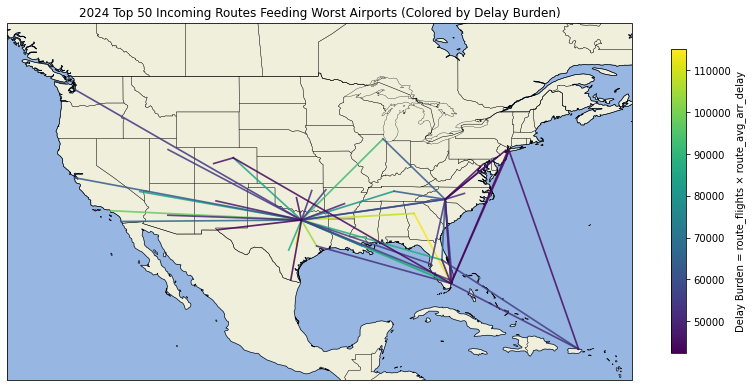

In [77]:
# Plot incoming routes feeding worst airports (colored by delay burden)

import matplotlib.pyplot as plt # Plotting
import matplotlib as mpl # Colormap utilities
import cartopy.crs as ccrs # Projections
import cartopy.feature as cfeature # Basemap features

fig = plt.figure(figsize=(14, 8)) # Create figure
ax = plt.axes(projection=ccrs.PlateCarree()) # Create Cartopy axis

ax.set_title(f"2024 Top {N} Incoming Routes Feeding Worst Airports (Colored by Delay Burden)") # Title

ax.add_feature(cfeature.LAND) # Land
ax.add_feature(cfeature.OCEAN) # Ocean
ax.add_feature(cfeature.COASTLINE, linewidth=0.6) # Coastlines
ax.add_feature(cfeature.BORDERS, linewidth=0.5) # Borders
ax.add_feature(cfeature.STATES, linewidth=0.3) # States
ax.set_extent([-130, -60, 15, 55], crs=ccrs.PlateCarree()) # Extent includes PR/VI if needed

vmin = routes_in_map["delay_burden"].min() # Min burden for color scaling
vmax = routes_in_map["delay_burden"].max() # Max burden for color scaling
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax) # Normalize values
cmap = plt.cm.viridis # Colormap

for _, r in routes_in_map.iterrows(): # Plot each route
    x, y = r["geometry"].xy # Extract coordinates
    ax.plot(x, y, linewidth=1.7, alpha=0.85, color=cmap(norm(r["delay_burden"])), transform=ccrs.PlateCarree()) # Line colored by burden

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap) # Scalar mappable for colorbar
sm.set_array([]) # Required for colorbar
cbar = plt.colorbar(sm, ax=ax, shrink=0.7) # Add colorbar
cbar.set_label("Delay Burden = route_flights × route_avg_arr_delay") # Label

plt.show() # Show plot

### What we observed from routes feeding the worst airports

The map shows the top 50 incoming routes (by delay burden = route_flights × route_avg_arr_delay) whose destinations are the worst-performing airports identified earlier. Each line represents an origin–destination pair, and darker/brighter colors indicate routes that combine high delay with high traffic volume, making them especially important contributors to overall delay impact.

Visually, the highest-burden incoming routes concentrate around a few major destination hubs. A large share of the lines converge into the Dallas–Fort Worth region, indicating that many of the most impactful incoming connections feed into DFW. We also see strong clustering into Florida destinations (consistent with several worst-airport candidates in the state and heavy travel demand), and a smaller but noticeable set of high-burden routes involving the New York area. Overall, the pattern suggests that delay burden is driven by a limited number of high-traffic corridors feeding into major hubs, rather than being evenly distributed across all airports and routes.

## 8. Results & Concluding Discussion

This project was implemented on CyberGISX using a reproducible Jupyter Notebook workflow and a set of Python geospatial data science tools. We used pandas for reading, cleaning, filtering, grouping, and aggregating the BTS flight records. For vissualization, we relied on Matplotlib and Cartopy to produce consistent, comparable maps with the same projections, extents, and color scales when needed. Finally, we used Shapely vector operations to construct LineString geometries that represent origin–destination routes as lines on a map, allowing us to move from airport-level summaries to explicit network connection visualizations.

The analysis began with flight-level BTS on-time performance records and airport coordinates from OurAirports. After creating a season variable from the monthly data and separating canceled flights from non-canceled flights (since delay minutes are not meaningful for cancellations), we computed airport-level performance metrics for 2024, including total flight volume, percent canceled, percent delayed (arrival delay > 15 minutes), and average arrival delay using only non-canceled flights with valid arrival delay values. We then extended the same computations to a seasonal framework by aggregating by season and origin airport, enabling a direct comparison of delay hotspots across Winter, Spring, Summer, and Fall. Next, we computed route-level metrics for origin–destination pairs to identify the worst-performing high-volume routes. Finally, we connected these two levels of analysis by identifying a set of worst airports and ranking the high-volume routes feeding into those airports, including a delay burden measure defined as route volume multiplied by route average arrival delay. Throughout these steps, we applied a high-volume threshold (2000 flights) for rankings and comparisons to avoid small-sample outliers dominating the interpretation.

The seasonal airport maps show that delay hotspots are not static across the year. Because the four seasonal maps use a consistent color scale and are filtered to high-volume airports, differences across Winter, Spring, Summer, and Fall can be interpreted as meaningful seasonal shifts rather than artifacts of plotting. Visually, Winter and Summer exhibit more pronounced areas of higher average arrival delays at certain major airports, while Fall appears comparatively lower across many airports, suggesting fewer extreme hotspots during that season. These seasonal differences are important because they indicate that “where delays are worst” depends on when travel occurs, and they motivate looking into the specific connections that may be driving those seasonal outcomes.

The route-level maps in Section 6 highlight a different dimension of the problem by shifting the analysis from airports to origin–destination pairs. The worst high-volume routes line map displays the top delay-severity routes across the system, showing that high delays are concentrated along a limited set of major corridors and hub-connected links rather than being uniformly distributed across all routes. The airport-level route risk map, while also a point map, is different from the seasonal airport maps: instead of measuring airport-wide outcomes directly, it summarizes route performance back to origin airports by averaging route-level delays across each origin’s high-volume routes. This provides a network-oriented view of risk and helps distinguish airport performance from route structure.

Section 7 further narrows the focus by asking which routes contribute most to the delay impact at the worst airports, rather than identifying the worst routes globally. The incoming route burden map filters to routes whose destinations are in the worst airport set and ranks them by delay burden, combining both severity and volume. Visually, this map shows that the largest contributions to delay burden are concentrated along a relatively small number of inbound corridors that converge into major destination hubs. In our results, many high-impact routes converge into the Dallas-Fort Worth region, and there is also visible clustering into Florida destinations, with a smaller but noticeable concentration involving the New York area. This reinforces the interpretation that delay burden at worst-performing airports is not driven equally by every connection, and a small subset of high-traffic inbound routes can disproportionately shape overall performance.

These results are useful because they turn raw flight records into actionable geospatial insights at multiple levels. For passengers, seasonal hotspot maps can inform decisions about when and where delay risk is higher, which matters for connection planning and travel timing. For airport and airline operations, the combined airport-level and route-level views highlight where disruption concentrates and which specific corridors are most associated with high delay impact, supporting more targeted attention than airport-wide averages alone. At a system level, separating airport outcomes from route corridors helps clarify whether performance issues are localized airport constraints, network connection effects, or a combination of both.

There are several ways to extend this work. A natural next step is multi-year analysis, repeating the same seasonal computations for multiple years to show whether hotspots are stable or shifting over time, which directly addresses the temporal feedback that mapping changes across years is valuable. Another extension is weather attribution by integrating NOAA station variables such as wind, visibility, or precipitation proxies to test whether seasonal hotspots align with meteorological drivers. The route-risk metric could also be refined to be flight-weighted so that the average reflects the routes that carry the most volume more strongly, which would better represent overall burden at the origin airport. Finally, the maps could be made interactive in Folium to improve interpretability (it could have hover popups for airport and route metrics), and the aggregated tables could be stored and queried in PostGIS to demonstrate spatial database workflows and improve scalability for larger multi-year datasets.

AI Disclosure Statement: ChatGPT was used to resolve issues with coding and file extraction. Final implementation reflects my own understanding.